# $k$-Means Clustering (Unsupervised Learning) and One-HOT Encoding

Unsupervised means that we don't provide targets for the model, all that we have is the data.

Challenge: Write your own clustering algorithm

Defn: **Within-Cluster Variation (WCV)**. Measures the similarity (distance) between data points. We are measuring a Euclidian squared distance for k-means. WCV quantifies the degree of dispersion of data points within a cluster.

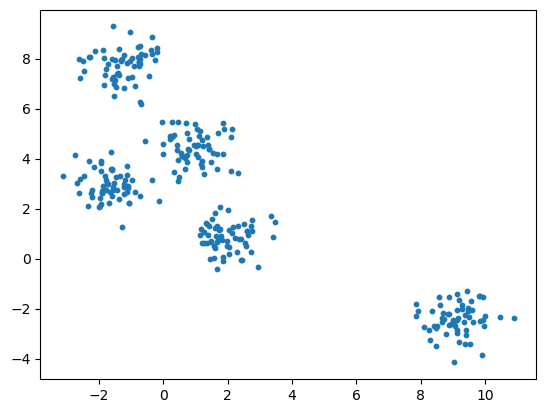

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=5, cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.show()

c:\Users\jairi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


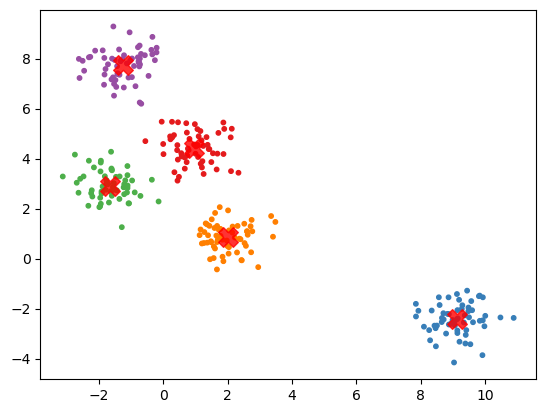

In [3]:
import matplotlib.colors as colors

# Training a k means 
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)

fixedcmap = colors.ListedColormap(['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'])

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap=fixedcmap, s=10)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X')
plt.show()

c:\Users\jairi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\jairi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\jairi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\jairi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Text(0.5, 1.0, 'Elbow Method For Optimal k')

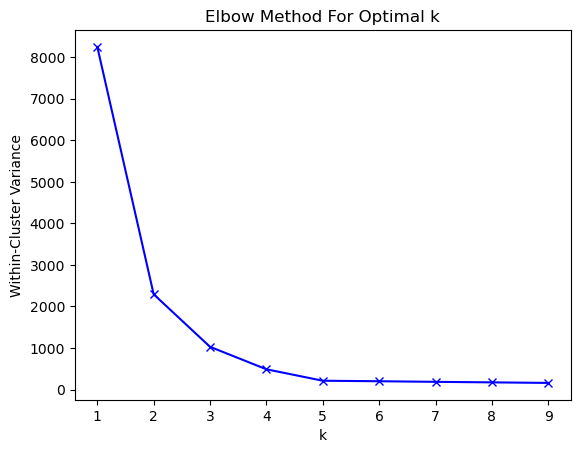

In [4]:
# Optimally finding the optimal k value
wcv = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    wcv.append(kmeans.inertia_)
plt.plot(K, wcv, 'bx-')
plt.xlabel('k')
plt.ylabel('Within-Cluster Variance')
plt.title('Elbow Method For Optimal k')

In [18]:
# Given some dirty data, we have to wrangle it (clean) before analysis
import pandas as pd
df = pd.read_csv('world-data-2023.csv')
df.head()

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [19]:
columns_to_remove = ['Country', 'Calling Code', 'Capital/Major City', 'Largest City', 'Latitude', 'Longitude']
df = df.drop(columns=columns_to_remove)
df.info()

KeyError: "['Largest City'] not found in axis"

In [20]:
''' Custom data wrangling stuff '''


def wrangle_cell( datum ):
    ''' Function to be mapped across entire dataframe to clean each cell '''
    retval = datum
    
    ...
    if isinstance(datum, str):
        # Strip whitespace
        retval = retval.strip()
        
        # Remove commas from numbers
        retval = datum.replace(',', '')
    
        # Integer
        if retval.isdigit():
            retval = int(retval)
            
        ...  # All other conversions and whatnot
            
    return retval

Now, we can map that on the entire dataframe.

In [ ]:
df_clean = df.map(wrangle_cell)  # Map the cleaning function across entire dataframe
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    int64  
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    float64
 5   Armed Forces size                          171 non-null    float64
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    float64
 10  CPI                       

<Axes: >

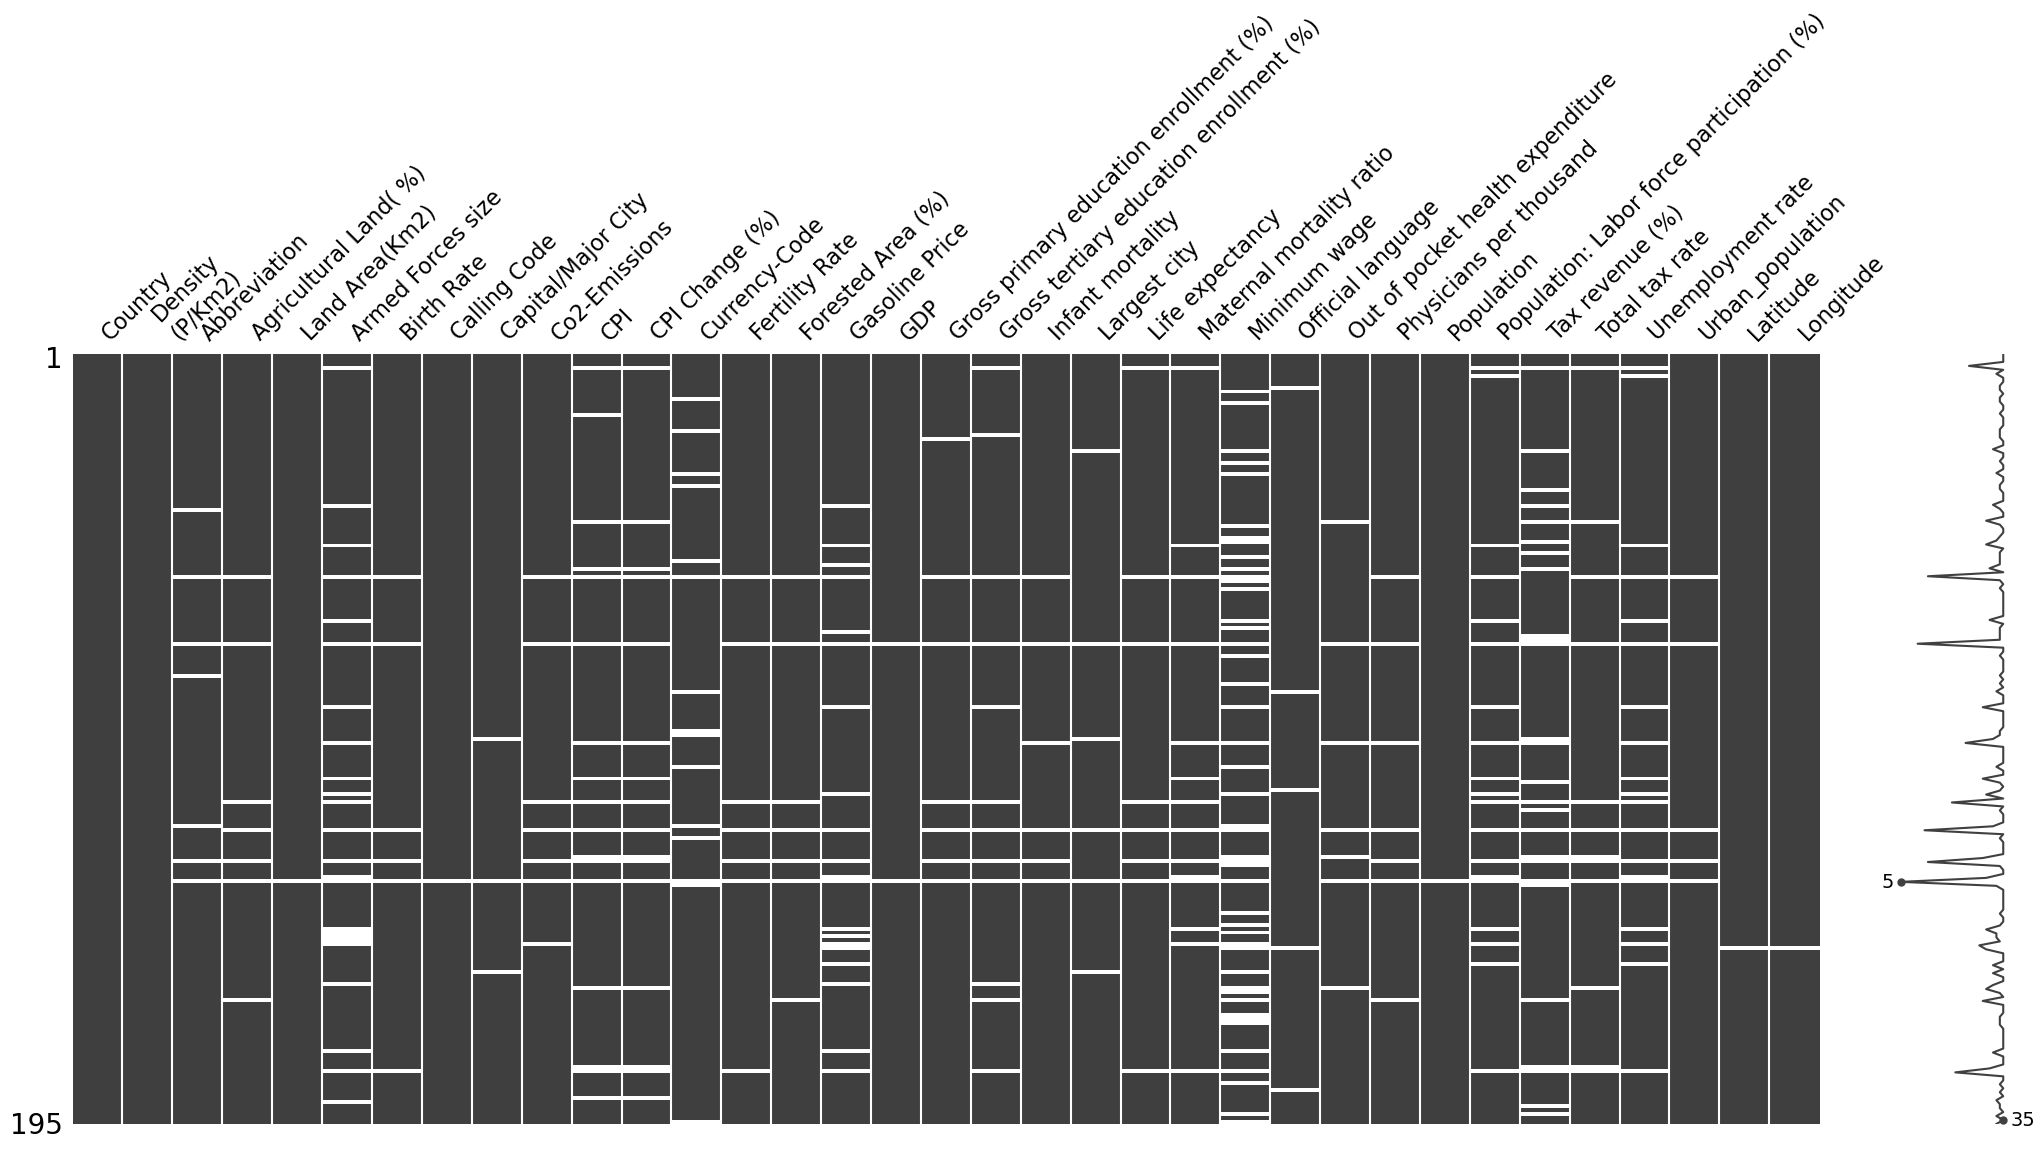

In [22]:
import missingno as msno
msno.matrix(df_clean)

challenge: Create that but interactive using plotly to see exactly what is missing.

In [ ]:
# Making the data conotacale 
df_clean = df_clean.replace('', np.nan)

# Remove in-place rows with missing data
df_clean.dropna(inplace=True)

In [ ]:
# Systematically exploring for the optimal number of centroids
# ...

# Reveal which country is in each cluster
print(df_country_names[ kmeans.labels_ == 0 ])  # Countries in cluster 

